In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score

In [3]:
df = pd.read_csv("Copy of heart.csv")
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [4]:
s_dum = pd.get_dummies(df.Sex)
s_dum

,F,M
0,False,True
1,True,False
2,False,True
3,True,False
4,False,True
...,...,...
913,False,True
914,False,True
915,False,True
916,True,False


In [5]:
dum_cp = pd.get_dummies(df.ChestPainType)
dum_cp

,ASY,ATA,NAP,TA
0,False,True,False,False
1,False,False,True,False
2,False,True,False,False
3,True,False,False,False
4,False,False,True,False
...,...,...,...,...
913,False,False,False,True
914,True,False,False,False
915,True,False,False,False
916,False,True,False,False


In [6]:
rest_dum = pd.get_dummies(df.RestingECG)
rest_dum

,LVH,Normal,ST
0,False,True,False
1,False,True,False
2,False,False,True
3,False,True,False
4,False,True,False
...,...,...,...
913,False,True,False
914,False,True,False
915,False,True,False
916,True,False,False


In [7]:
ex_dum = pd.get_dummies(df.ExerciseAngina)
ex_dum

,N,Y
0,True,False
1,True,False
2,True,False
3,False,True
4,True,False
...,...,...
913,True,False
914,True,False
915,False,True
916,True,False


In [8]:
st_dum = pd.get_dummies(df.ST_Slope)
st_dum

,Down,Flat,Up
0,False,False,True
1,False,True,False
2,False,False,True
3,False,True,False
4,False,False,True
...,...,...,...
913,False,True,False
914,False,True,False
915,False,True,False
916,False,True,False


In [10]:
X = pd.concat([df['Age'],s_dum, dum_cp, df.loc[:,['RestingBP','Cholesterol','FastingBS']], rest_dum, df['MaxHR'], ex_dum, df['Oldpeak'], st_dum],axis=1)
X

,Age,F,M,ASY,ATA,NAP,TA,RestingBP,Cholesterol,FastingBS,LVH,Normal,ST,MaxHR,N,Y,Oldpeak,Down,Flat,Up
0,40,False,True,False,True,False,False,140,289,0,False,True,False,172,True,False,0.0,False,False,True
1,49,True,False,False,False,True,False,160,180,0,False,True,False,156,True,False,1.0,False,True,False
2,37,False,True,False,True,False,False,130,283,0,False,False,True,98,True,False,0.0,False,False,True
3,48,True,False,True,False,False,False,138,214,0,False,True,False,108,False,True,1.5,False,True,False
4,54,False,True,False,False,True,False,150,195,0,False,True,False,122,True,False,0.0,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,False,True,False,False,False,True,110,264,0,False,True,False,132,True,False,1.2,False,True,False
914,68,False,True,True,False,False,False,144,193,1,False,True,False,141,True,False,3.4,False,True,False
915,57,False,True,True,False,False,False,130,131,0,False,True,False,115,False,True,1.2,False,True,False
916,57,True,False,False,True,False,False,130,236,0,True,False,False,174,True,False,0.0,False,True,False


In [11]:
y = df.HeartDisease
y

0      0
1      1
2      0
3      1
4      0
      ..
913    1
914    1
915    1
916    1
917    0
Name: HeartDisease, Length: 918, dtype: int64

In [12]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [13]:
mean_bp = df.RestingBP.mean()
df['RestingBP'] = df['RestingBP'].replace(0, mean_bp)
df['Cholesterol'] = df['Cholesterol'].replace(0, df.Cholesterol.mean())
df['FastingBS'] = df['FastingBS'].replace(0, df.FastingBS.mean())
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0.233115,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0.233115,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0.233115,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0.233115,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0.233115,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110.0,264.0,0.233115,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144.0,193.0,1.000000,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130.0,131.0,0.233115,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130.0,236.0,0.233115,LVH,174,N,0.0,Flat,1


In [14]:
df[df.RestingBP==0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease


In [16]:
df = pd.get_dummies(df)
df

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0.233115,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160.0,180.0,0.233115,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0.233115,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138.0,214.0,0.233115,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150.0,195.0,0.233115,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0.233115,132,1.2,1,False,True,False,...,False,True,False,True,False,True,False,False,True,False
914,68,144.0,193.0,1.000000,141,3.4,1,False,True,True,...,False,False,False,True,False,True,False,False,True,False
915,57,130.0,131.0,0.233115,115,1.2,1,False,True,True,...,False,False,False,True,False,False,True,False,True,False
916,57,130.0,236.0,0.233115,174,0.0,1,True,False,False,...,False,False,True,False,False,True,False,False,True,False


In [17]:
X = df.drop('HeartDisease',axis='columns')
y = df.HeartDisease
print(X)
print(y)

     Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  Sex_F  Sex_M  \
0     40      140.0        289.0   0.233115    172      0.0  False   True   
1     49      160.0        180.0   0.233115    156      1.0   True  False   
2     37      130.0        283.0   0.233115     98      0.0  False   True   
3     48      138.0        214.0   0.233115    108      1.5   True  False   
4     54      150.0        195.0   0.233115    122      0.0  False   True   
..   ...        ...          ...        ...    ...      ...    ...    ...   
913   45      110.0        264.0   0.233115    132      1.2  False   True   
914   68      144.0        193.0   1.000000    141      3.4  False   True   
915   57      130.0        131.0   0.233115    115      1.2  False   True   
916   57      130.0        236.0   0.233115    174      0.0   True  False   
917   38      138.0        175.0   0.233115    173      0.0  False   True   

     ChestPainType_ASY  ChestPainType_ATA  ChestPainType_NAP  \
0          

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [20]:
rf = cross_val_score(RandomForestClassifier(n_estimators=35),X_train, y_train)

print(rf)

[0.8707483  0.88435374 0.85034014 0.85714286 0.8630137 ]


In [21]:
lr = cross_val_score(LogisticRegression(max_iter=5000),X_train, y_train)

print(lr)

[0.85034014 0.9047619  0.8707483  0.82312925 0.89726027]


In [22]:
model = KNeighborsClassifier(n_neighbors=9)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.6630434782608695

In [23]:
scalar = StandardScaler()
scaled_x = scalar.fit_transform(X)
scaled_x.shape

(918, 20)

In [24]:
pca = PCA(0.95)
x_pca = pca.fit_transform(scaled_x)
x_pca.shape

(918, 13)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(x_pca, y, test_size=0.2)

In [26]:
model = KNeighborsClassifier(n_neighbors=9)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.8478260869565217

In [27]:
rf = cross_val_score(RandomForestClassifier(n_estimators=35),X_train, y_train)

print(rf)

[0.85034014 0.79591837 0.8707483  0.86394558 0.88356164]


In [28]:
lr = cross_val_score(LogisticRegression(max_iter=150),X_train, y_train)

print(lr)

[0.82993197 0.82312925 0.85034014 0.8707483  0.86986301]


PCA VARIANCE EXPERIMENT
Original features: 20
Total samples: 918


Variance = 90.0%
   Components: 12
   Explained variance: 0.9126
   KNN Accuracy: 0.8424

Variance = 95.0%
   Components: 13
   Explained variance: 0.9501
   KNN Accuracy: 0.8424

Variance = 99.0%
   Components: 15
   Explained variance: 1.0000
   KNN Accuracy: 0.8424

COMPARISON TABLE
Variance 90%: 12 components → Accuracy: 0.8424
Variance 95%: 13 components → Accuracy: 0.8424
Variance 99%: 15 components → Accuracy: 0.8424

Best: Variance 90% with 12 components


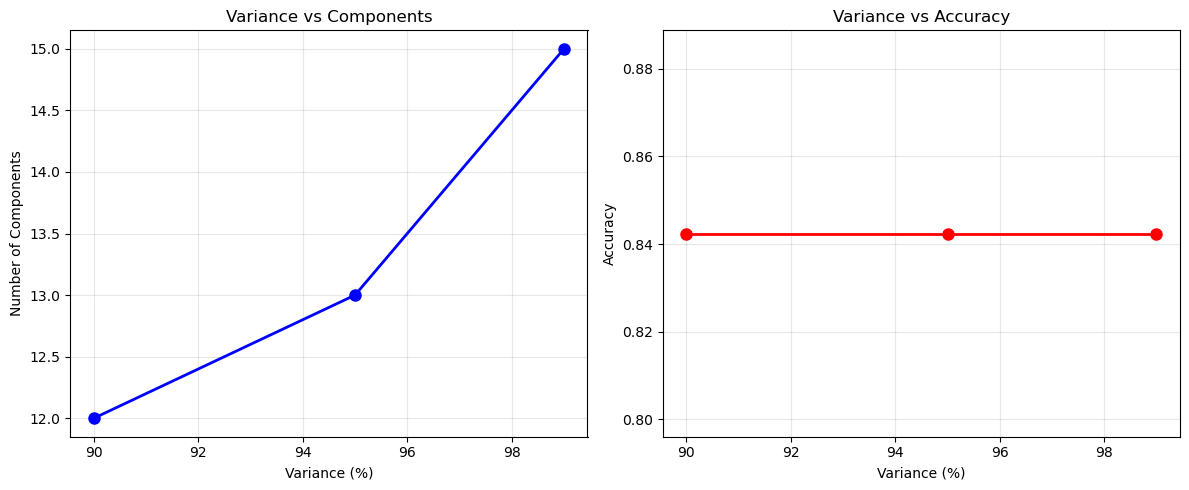

Higher variance = More components but Better Accuracy.


In [32]:
# PCA VARIANCE EXPERIMENT - SIMPLE SOLUTION
# Try different variance values and compare

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# LOAD DATA 
df = pd.read_csv("Copy of heart.csv")

# PREPROCESS 
# Convert categorical to numeric
df = pd.get_dummies(df)

# Handle missing values (0 values)
df['RestingBP'] = df['RestingBP'].replace(0, df['RestingBP'].mean())
df['Cholesterol'] = df['Cholesterol'].replace(0, df['Cholesterol'].mean())

# DEFINE X AND y
X = df.drop('HeartDisease', axis='columns')
y = df['HeartDisease']

# SCALE DATA (Important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("PCA VARIANCE EXPERIMENT")
print(f"Original features: {X.shape[1]}")
print(f"Total samples: {X.shape[0]}\n")

# TRY DIFFERENT VARIANCES 
variance_values = [0.90, 0.95, 0.99]
results = []

for var in variance_values:
    print(f"\nVariance = {var*100}%")
    
    # Apply PCA
    pca = PCA(var)
    X_pca = pca.fit_transform(X_scaled)
    
    print(f"   Components: {X_pca.shape[1]}")
    print(f"   Explained variance: {sum(pca.explained_variance_ratio_):.4f}")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_pca, y, test_size=0.2, random_state=42
    )
    
    # Train KNN
    model = KNeighborsClassifier(n_neighbors=9)
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    
    print(f"   KNN Accuracy: {score:.4f}")
    
    # Store results
    results.append({
        'variance': var,
        'components': X_pca.shape[1],
        'accuracy': score
    })

# COMPARE RESULTS
print("\nCOMPARISON TABLE")

for r in results:
    print(f"Variance {r['variance']*100:.0f}%: {r['components']} components → Accuracy: {r['accuracy']:.4f}")

# FIND BEST
best = max(results, key=lambda x: x['accuracy'])
print(f"\nBest: Variance {best['variance']*100:.0f}% with {best['components']} components")

# PLOT RESULTS
plt.figure(figsize=(12, 5))

# Plot 1: Components vs Variance
plt.subplot(1, 2, 1)
vars_plot = [r['variance']*100 for r in results]
comps_plot = [r['components'] for r in results]
plt.plot(vars_plot, comps_plot, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Variance (%)')
plt.ylabel('Number of Components')
plt.title('Variance vs Components')
plt.grid(True, alpha=0.3)

# Plot 2: Accuracy vs Variance
plt.subplot(1, 2, 2)
acc_plot = [r['accuracy'] for r in results]
plt.plot(vars_plot, acc_plot, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Variance (%)')
plt.ylabel('Accuracy')
plt.title('Variance vs Accuracy')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Higher variance = More components but Better Accuracy.")